# Meteora DLMM Bin Atlas: connecting, fetching, normalizing, visualizing

This notebook explores Meteora DLMM bin-level liquidity using a read-only Solana RPC connection. It does not run a Solana node, does not use a wallet, and does not submit transactions.

## Environment

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.parse import urlparse
from dotenv import load_dotenv

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
PLOTS_DIR = PROJECT_ROOT / "plots"

load_dotenv(PROJECT_ROOT / ".env")


def latest_matching(directory: Path, pattern: str) -> Path:
    matches = sorted(directory.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matching {pattern} in {directory}")
    return matches[-1]


print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/echow/Desktop/meteora_bin_atlas


## RPC model

We connect through an RPC provider using `SOLANA_RPC_URL`. This is read-only. We never print the full URL (it may contain API keys).

In [2]:
rpc_url = os.getenv("SOLANA_RPC_URL", "")
rpc_host = urlparse(rpc_url).hostname or "(not set)"
cluster = os.getenv("SOLANA_CLUSTER", "mainnet-beta")

print(f"RPC host: {rpc_host}")
print(f"Cluster: {cluster}")

RPC host: api.mainnet-beta.solana.com
Cluster: mainnet-beta


## Fetch pool candidates

Run the TypeScript discovery script, then load the processed CSV.

In [3]:
!cd {PROJECT_ROOT} && npm run discover:pools


> meteora-bin-atlas@0.1.0 discover:pools
> tsx src/scripts/step1_discover_pools.ts

Discovery method: meteora_api
Candidate pools: 10
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/pools_2026-06-07T05-15-10-593Z.json
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/pool_candidates.csv
Warnings:
- Legacy Meteora API https://dlmm-api.meteora.ag/pair/all returned HTTP 404; using https://dlmm.datapi.meteora.ag/pools instead.
Pool discovery complete.
⠙

In [4]:
pool_candidates_path = DATA_PROCESSED / "pool_candidates.csv"
pool_candidates = pd.read_csv(pool_candidates_path)
pool_candidates.head()

,pool_address,token_x_mint,token_y_mint,bin_step,active_bin_id,raw_name_or_symbol_if_available,source,fetched_at_utc
0,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,So11111111111111111111111111111111111111112,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,4,-6868,SOL-USDC,meteora_api,2026-06-07T05:15:10.594Z
1,9p3aRWnbu5vAmHXvsToMGfwmbkTJSwGr5G5xxSxmkB8N,CWZ6BsdnjkDVTGkmL6bGbJXXig6ceef12KvyGQW14cMt,Es9vMFrzaCERmJfrF4H2FYD4KCoNkY11McCe8BenwNYB,80,-490,ANTFUN-USDT,meteora_api,2026-06-07T05:15:10.594Z
2,ANCx141SujgVdbKz9NTEH8F38qWsnyyXsVju64aU3qLB,98sMhvDwXj1RQi5c5Mndm3vPe9cBqPrbLaufMXFNMh5g,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,20,-1412,HYPE-USDC,meteora_api,2026-06-07T05:15:10.594Z
3,7ubS3GccjhQY99AYNKXjNJqnXjaokEdfdV915xnCb96r,cbbtcf3aa214zXHbiAZQwf4122FBYbraNdFqgw4iMij,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,4,16072,cbBTC-USDC,meteora_api,2026-06-07T05:15:10.594Z
4,HcCbiQqc55uHtP2MJu7BYdVPi9s4j45R4zXcwRmJgCXX,So11111111111111111111111111111111111111112,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,5,-5494,SOL-USDC,meteora_api,2026-06-07T05:15:10.594Z


## Choose one pool

Use the first discovered candidate, or set `POOL_ADDRESS` manually.

In [5]:
POOL_ADDRESS = pool_candidates.iloc[0]["pool_address"]
# POOL_ADDRESS = "5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6"

selected = pool_candidates[pool_candidates["pool_address"] == POOL_ADDRESS].iloc[0]
print(f"Pool: {POOL_ADDRESS}")
print(f"Label: {selected.get('raw_name_or_symbol_if_available', '')}")
print(f"Bin step: {selected.get('bin_step', '')}")

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Label: SOL-USDC
Bin step: 4


## Fetch pool snapshot

In [6]:
!cd {PROJECT_ROOT} && npm run fetch:pool -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 fetch:pool
> tsx src/scripts/step2_fetch_pool_snapshot.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Active bin ID: -6869
Active bin price: 64.11668666832709893
Bin step: 4 bps
Token X mint: So11111111111111111111111111111111111111112
Token Y mint: EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/pool_snapshot_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-15-12-975Z.json
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/pool_snapshot_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-15-12-975Z.json
Pool snapshot complete.
⠙

## Fetch bin arrays

In [7]:
!cd {PROJECT_ROOT} && npm run fetch:bins -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 fetch:bins
> tsx src/scripts/step3_fetch_bin_arrays.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Method: getBinArrays
Bin arrays fetched: 195
Active bin ID: -6869
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/bin_arrays_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-15-14-094Z.json
Bin arrays fetch complete.
⠙

## Normalize bin atlas

In [8]:
!cd {PROJECT_ROOT} && npm run normalize:bins -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 normalize:bins
> tsx src/scripts/step4_normalize_bin_atlas.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Input: /Users/echow/Desktop/meteora_bin_atlas/data/raw/bin_arrays_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-15-14-094Z.json
Method: getBinArrays
Bins normalized: 13650
Active bin rows: 1
Bins with non-zero liquidity: 4978
Active bin ID: -6869
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/bin_atlas_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-15-14-095Z.csv
Bin atlas normalization complete.
⠙

## Load bin atlas

In [9]:
latest_bin_atlas_path = latest_matching(
    DATA_PROCESSED, f"bin_atlas_{POOL_ADDRESS}_*.csv"
)
df = pd.read_csv(latest_bin_atlas_path)
print(f"Loaded: {latest_bin_atlas_path.name}")
df.head()

Loaded: bin_atlas_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-15-14-095Z.csv


,pool_address,fetched_at_utc,bin_array_index,bin_id,distance_from_active,price,price_per_token,liquidity,x_amount,y_amount,composition_y,is_active_bin,raw_bin_array_pubkey,raw_fields_json
0,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:15:14.095Z,-456,-31920,-25051,52717705093411,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52717705..."
1,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:15:14.095Z,-456,-31919,-25050,52738792175449,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52738792..."
2,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:15:14.095Z,-456,-31918,-25049,52759887692319,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52759887..."
3,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:15:14.095Z,-456,-31917,-25048,52780991647396,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52780991..."
4,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:15:14.095Z,-456,-31916,-25047,52802104044055,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52802104..."


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13650 entries, 0 to 13649
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pool_address          13650 non-null  str    
 1   fetched_at_utc        13650 non-null  str    
 2   bin_array_index       13650 non-null  int64  
 3   bin_id                13650 non-null  int64  
 4   distance_from_active  13650 non-null  int64  
 5   price                 13650 non-null  object 
 6   price_per_token       0 non-null      float64
 7   liquidity             13650 non-null  object 
 8   x_amount              13650 non-null  int64  
 9   y_amount              13650 non-null  int64  
 10  composition_y         4978 non-null   float64
 11  is_active_bin         13650 non-null  bool   
 12  raw_bin_array_pubkey  13650 non-null  str    
 13  raw_fields_json       13650 non-null  str    
dtypes: bool(1), float64(2), int64(5), object(2), str(4)
memory usage: 8.3+ MB


## Basic sanity checks

In [11]:
print("bin_id range:", df["bin_id"].min(), df["bin_id"].max())
print(
    "distance_from_active range:",
    df["distance_from_active"].min(),
    df["distance_from_active"].max(),
)
print("active bin rows:", df["is_active_bin"].astype(str).str.lower().eq("true").sum())

# Zoom window for plots (bins on each side of active)
ZOOM_BINS = 30

neighborhood_df = (
    df[df["distance_from_active"].between(-ZOOM_BINS, ZOOM_BINS)]
    .sort_values("bin_id")
    .copy()
)
neighborhood_df["liquidity"] = pd.to_numeric(neighborhood_df["liquidity"], errors="coerce").fillna(0)
neighborhood_df["x_amount"] = pd.to_numeric(neighborhood_df["x_amount"], errors="coerce").fillna(0)
neighborhood_df["y_amount"] = pd.to_numeric(neighborhood_df["y_amount"], errors="coerce").fillna(0)

print(f"\nNeighborhood rows (±{ZOOM_BINS} bins):", len(neighborhood_df))
print(
    neighborhood_df[
        ["distance_from_active", "bin_id", "x_amount", "y_amount", "is_active_bin"]
    ].to_string(index=False)
)

bin_id range: -31920 30379
distance_from_active range: -25051 37248
active bin rows: 1


## DLMM side structure (why X and Y split around the active bin)

In a DLMM pool, liquidity is **not** symmetric around the active bin:

- **Bins below** the active bin (`distance_from_active < 0`) hold **token Y** (here: USDC). These are the bid side — liquidity waiting if price moves down.
- **Bins above** the active bin (`distance_from_active > 0`) hold **token X** (here: SOL). These are the ask side — liquidity waiting if price moves up.
- The **active bin** is the handoff: it typically holds a small mix of both as price sits on the boundary.

So it is normal to see **no Y on the ask side** and **no X on the bid side**. The data is not missing; that is how the lattice is laid out.

The plots below zoom to ±`ZOOM_BINS` around the active bin. Full-pool plots compress this neighborhood into an unreadable sliver.

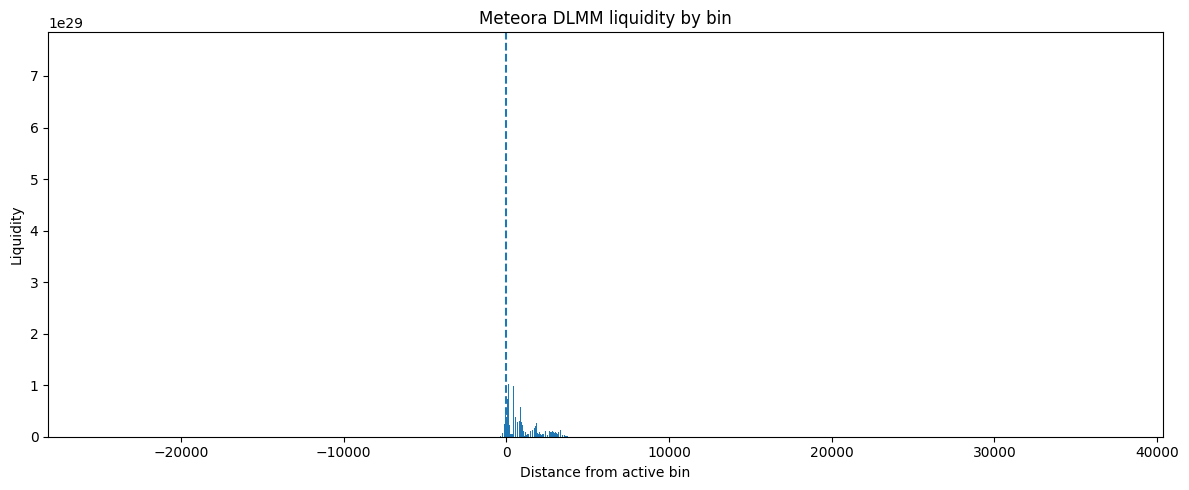

In [12]:
plot_df = neighborhood_df

fig, ax = plt.subplots(figsize=(14, 6))
bar_width = 0.8
ax.bar(
    plot_df["distance_from_active"],
    plot_df["liquidity"],
    width=bar_width,
)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlim(-ZOOM_BINS - 1, ZOOM_BINS + 1)
ax.set_xlabel("Distance from active bin")
ax.set_ylabel("Liquidity (raw on-chain units)")
ax.set_title(f"Meteora DLMM liquidity by bin (±{ZOOM_BINS} around active)")
fig.tight_layout()
plt.show()

## Visualize token composition

If x/y amounts exist, plot them around the active bin. Amounts are raw on-chain units (not decimal-adjusted).

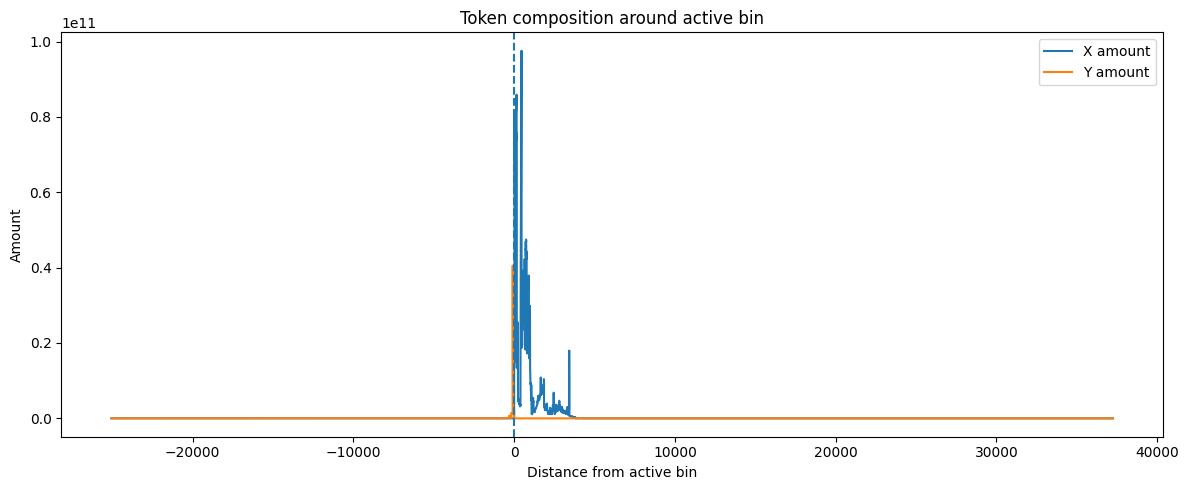

In [13]:
plot_df = neighborhood_df

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

bid_side = plot_df[plot_df["distance_from_active"] <= 0]
ask_side = plot_df[plot_df["distance_from_active"] >= 0]

axes[0].bar(
    bid_side["distance_from_active"],
    bid_side["y_amount"],
    width=0.8,
    label="Y amount (bid side)",
)
axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].set_ylabel("Y amount (raw)")
axes[0].set_title("Bid side: USDC (Y) below active bin")
axes[0].legend(loc="upper right")

axes[1].bar(
    ask_side["distance_from_active"],
    ask_side["x_amount"],
    width=0.8,
    label="X amount (ask side)",
)
axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_xlim(-ZOOM_BINS - 1, ZOOM_BINS + 1)
axes[1].set_xlabel("Distance from active bin")
axes[1].set_ylabel("X amount (raw)")
axes[1].set_title("Ask side: SOL (X) above active bin")
axes[1].legend(loc="upper right")

fig.suptitle(f"Token composition around active bin (±{ZOOM_BINS})", y=1.02)
fig.tight_layout()
plt.show()

## Microstructure notes

The active bin functions as a local coordinate center. Liquidity away from the active bin is a discrete field over price bins. A single snapshot gives the static shape; repeated snapshots would show migration and deformation.

## Next questions

- How concentrated is liquidity around the active bin?
- How asymmetric is liquidity on either side?
- How does the active bin move over time?
- Do volatile pools show wider liquidity distributions?
- How do stable pools differ from memecoin or SOL pairs?